# 네트워크 침입 탐지 — MLflow Pipeline v7

## 가설 H7: 알려진 공격을 먼저 제거한 뒤 Residual에서 Timestamp로 Infilteration을 찾는다

v6는 `Benign vs Attack → 공격 유형` 순서였습니다. v7는 문제를 반대로 구성합니다.

1. Stage 1A: `Benign` vs `Attack` 이진 게이트
2. Stage 1B: 공격 전용 4종 분류기에서 알려진 3종만 높은 Attack 확률로 확정
3. 나머지 Residual을 `Benign vs Infilteration` 전용 Stage 2로 재판정

Residual Stage 2는 다음 세 구성을 비교합니다.

- `flow_only`: 시간 피처 제외
- `timestamp_only`: 시간대·요일·경과시간만 사용
- `timestamp_context_flow`: Timestamp + 과거 문맥 + Flow 전체 사용

Stage 1 신뢰도와 Stage 2 Infilteration 임계값을 함께 탐색합니다. 또한 2월 28일까지 학습하고
3월 1일을 검증하는 날짜 Holdout으로 Timestamp 날짜 암기 여부를 별도 진단합니다.


In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

HYPOTHESIS_ID = "v7"
HYPOTHESIS = "known_attacks_first_then_timestamp_residual_specialist"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()
PROJECT_NAME = cwd.parent.name if cwd.name == "notebooks" else "network-classification"
PROJECT_DIR = WORK_ROOT / PROJECT_NAME
DATA_BASE = WORK_ROOT / "datasets"

def has_temporal_train(path: Path) -> bool:
    return (path / "processed" / "train_temporal_v5.parquet").exists()

preferred = DATA_BASE / PROJECT_NAME
if has_temporal_train(preferred):
    DATA_ROOT = preferred
else:
    matches = [p for p in DATA_BASE.iterdir() if p.is_dir() and has_temporal_train(p)]
    if len(matches) != 1:
        raise RuntimeError(f"Temporal 데이터 프로젝트를 결정할 수 없습니다: {matches}")
    DATA_ROOT = matches[0]

PROCESSED_DIR = DATA_ROOT / "processed"
TRAIN_TEMPORAL = PROCESSED_DIR / "train_temporal_v5.parquet"
TEST_TEMPORAL = PROCESSED_DIR / "test_temporal_v5.parquet"
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
KNOWN_ATTACKS = ["Brute Force", "DDOS", "DoS"]
RESIDUAL_LABEL = "Residual"
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20

CONTEXT_FEATURES = [
    "prev_distinct_ts_gap_s",
    "prior_events_10s_per_million",
    "prior_events_60s_per_million",
    "prior_events_300s_per_million",
    "prior_flow_pkts_s_mean_60s",
    "prior_flow_byts_s_mean_60s",
    "prior_total_pkts_mean_60s",
]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TEMPORAL_FEATURES = [*CONTEXT_FEATURES, *CALENDAR_FEATURES]

KNOWN_THRESHOLDS = [0.25, 0.35, 0.45, 0.55, 0.65]
INF_THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
RESIDUAL_INF_WEIGHT_MULTIPLIER = 0.25

V6_BASELINE = {
    "weighted_f1_attacks": 0.9202514012197288,
    "macro_f1_attacks": 0.7541476007767233,
    "accuracy": 0.9089381451548372,
    "infilteration_precision": 0.09265507396833636,
    "infilteration_recall": 0.4594594594594595,
    "infilteration_f1": 0.15421166306695464,
    "benign_to_infilteration_fp": 3496,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids-{HYPOTHESIS_ID}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Project    :", PROJECT_NAME)
print("Data root  :", DATA_ROOT)
print("Output     :", OUTPUT_DIR)
print("Experiment :", EXPERIMENT_NAME)


Project    : network-classification
Data root  : /home/jovyan/work/datasets/ 📁 network-classification
Output     : /home/jovyan/work/network-classification/outputs/v7
Experiment : network-classification-ids-v7


## 1. v5 시간 Parquet 샘플과 IDS 피처 로딩

In [2]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def load_sample(path: Path, n_rows: int):
    with duckdb.connect() as con:
        return con.execute(f'''
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

def add_ids_features(df: pd.DataFrame):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    if all(c in df.columns for c in flag_cols):
        values = {
            c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float)
            for c in flag_cols
        }
        syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
        rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
        urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
        total_flags = syn + ack + rst + fin + urg + psh + 1.0
        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_features(load_sample(TRAIN_TEMPORAL, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
INFILTRATION_LABEL = next(
    c for c in classes if c.lower() in {"infiltration", "infilteration"}
)

X_full = train_df.drop(columns=[TARGET, ID_COL, "Timestamp"], errors="ignore")
X_flow = X_full.drop(columns=TEMPORAL_FEATURES, errors="ignore")
X_router = X_full.drop(columns=CALENDAR_FEATURES, errors="ignore")
X_timestamp = X_full[CALENDAR_FEATURES].copy()

X_stage2_sets = {
    "flow_only": X_flow,
    "timestamp_only": X_timestamp,
    "timestamp_context_flow": X_full,
}

for frame in [X_flow, X_router, X_timestamp, X_full]:
    for column in CAT_FEATURES:
        if column in frame.columns:
            frame[column] = frame[column].astype("string")

print("Loaded:", train_df.shape)
print("Stage 1 features:", X_router.shape[1])
print("Stage 2 feature counts:", {k: v.shape[1] for k, v in X_stage2_sets.items()})


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded: (250000, 62)
Stage 1 features: 54
Stage 2 feature counts: {'flow_only': 47, 'timestamp_only': 5, 'timestamp_context_flow': 59}


## 2. v6와 동일한 클래스별 시간 블록 분할

In [3]:
class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
cutoff_per_row = train_df[TARGET].map(class_cutoffs)
valid_mask = train_df["Timestamp"] > cutoff_per_row
train_mask = ~valid_mask
y_train, y_valid = y_all.loc[train_mask], y_all.loc[valid_mask]

split_distribution = pd.crosstab(
    pd.Series(np.where(valid_mask, "valid_late", "train_early"), index=train_df.index),
    y_all,
)
display(class_cutoffs.to_frame("cutoff"))
display(split_distribution)
assert (split_distribution > 0).all().all()
print("Train rows:", int(train_mask.sum()), "Valid rows:", int(valid_mask.sum()))


,cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


Train rows: 200012 Valid rows: 49988


In [4]:
def make_preprocessor(frame):
    cat_features = [c for c in CAT_FEATURES if c in frame.columns]
    num_features = [c for c in frame.columns if c not in cat_features]
    transformers = []
    if num_features:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler()),
        ]), num_features))
    if cat_features:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_features))
    return ColumnTransformer(transformers)

def make_lgbm(objective, class_weight, n_estimators=500):
    return LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective=objective,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

def evaluate(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="weighted", zero_division=0,
        )),
        "macro_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="macro", zero_division=0,
        )),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    metric_labels = [
        (INFILTRATION_LABEL, "infilteration"),
        ("Brute Force", "bruteforce"),
        ("DDOS", "ddos"),
        ("DoS", "dos"),
    ]
    for label, prefix in metric_labels:
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[label], average=None, zero_division=0
        )
        metrics[f"{prefix}_precision"] = float(p[0])
        metrics[f"{prefix}_recall"] = float(r[0])
        metrics[f"{prefix}_f1"] = float(f[0])
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    metrics["benign_to_infilteration_fp"] = int(np.sum(
        (yt == "Benign") & (yp == INFILTRATION_LABEL)
    ))
    metrics["infilteration_routed_to_known"] = int(np.sum(
        (yt == INFILTRATION_LABEL) & np.isin(yp, KNOWN_ATTACKS)
    ))
    return metrics

def save_evaluation(name, y_true, y_pred):
    report_path = OUTPUT_DIR / f"{name}_classification_report.csv"
    pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, output_dict=True, zero_division=0
    )).T.to_csv(report_path, encoding="utf-8-sig")
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set(title=f"Confusion Matrix — {name}", xlabel="Predicted", ylabel="Actual")
    plt.tight_layout()
    cm_path = OUTPUT_DIR / f"{name}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    return report_path, cm_path


## 3. Stage 1 — v6 기반 알려진 공격 라우터

이진 Attack 게이트와 공격 4종 전용 분류기를 결합합니다. Attack 확률이 임계값 이상이고
공격 전용 분류 결과가 DDOS/DoS/Brute Force일 때만 알려진 공격으로 확정합니다.


In [5]:
y_attack_binary_train = (y_train != "Benign").astype(int)
attack_train_mask = train_mask & (y_all != "Benign")
y_attack_subtype_train = y_all.loc[attack_train_mask]

attack_gate = Pipeline([
    ("preprocess", make_preprocessor(X_router)),
    ("model", make_lgbm("binary", "balanced", n_estimators=400)),
])
subtype_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.asarray(attack_classes),
    y=y_attack_subtype_train.to_numpy(),
)
subtype_weights = dict(zip(attack_classes, subtype_weight_values.astype(float)))
attack_subtype = Pipeline([
    ("preprocess", make_preprocessor(X_router)),
    ("model", make_lgbm("multiclass", subtype_weights)),
])

started = time.time()
attack_gate.fit(X_router.loc[train_mask], y_attack_binary_train)
attack_subtype.fit(X_router.loc[attack_train_mask], y_attack_subtype_train)
router_attack_probability = attack_gate.predict_proba(X_router.loc[valid_mask])[:, 1]
router_valid_label = attack_subtype.predict(X_router.loc[valid_mask])

print("Router train seconds:", time.time() - started)
print("Subtype classes:", attack_subtype.named_steps["model"].classes_)
display(pd.Series(router_attack_probability).describe(
    percentiles=[.1, .25, .5, .75, .9, .95]
))


Router train seconds: 10.535662174224854
Subtype classes: ['Brute Force' 'DDOS' 'DoS' 'Infilteration']


count    49988.000000
mean         0.371327
std          0.451667
min          0.000006
10%          0.000107
25%          0.000369
50%          0.015031
75%          0.999928
90%          0.999996
95%          0.999996
max          0.999997
dtype: float64

## 4. Stage 2 — Residual 전용 세 모델

In [6]:
residual_train_mask = train_mask & y_all.isin(["Benign", INFILTRATION_LABEL])
y_residual_train = (y_all.loc[residual_train_mask] == INFILTRATION_LABEL).astype(int)
residual_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.asarray([0, 1]),
    y=y_residual_train.to_numpy(),
)
residual_weights = dict(zip([0, 1], residual_weight_values.astype(float)))
residual_weights[1] *= RESIDUAL_INF_WEIGHT_MULTIPLIER

stage2_models = {}
stage2_valid_probabilities = {}
stage2_train_seconds = {}

for feature_set, frame in X_stage2_sets.items():
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(frame)),
        ("model", make_lgbm("binary", residual_weights, n_estimators=400)),
    ])
    started = time.time()
    pipeline.fit(frame.loc[residual_train_mask], y_residual_train)
    stage2_models[feature_set] = pipeline
    stage2_valid_probabilities[feature_set] = pipeline.predict_proba(
        frame.loc[valid_mask]
    )[:, 1]
    stage2_train_seconds[feature_set] = time.time() - started
    print(feature_set, "train_seconds=", stage2_train_seconds[feature_set])

print("Residual train distribution")
display(y_all.loc[residual_train_mask].value_counts().to_frame("count"))
print("Residual class weights:", residual_weights)


flow_only train_seconds= 3.263472318649292


timestamp_only train_seconds= 0.6147243976593018


timestamp_context_flow train_seconds= 3.4898290634155273
Residual train distribution


,count
Label,
Benign,137495
Infilteration,3132


Residual class weights: {0: np.float64(0.5113895050729117), 1: np.float64(5.612507982120051)}


## 5. Stage 1 신뢰도 × Stage 2 Infilteration 임계값 탐색

In [7]:
candidate_rows = []

for feature_set, inf_probability in stage2_valid_probabilities.items():
    for known_threshold in KNOWN_THRESHOLDS:
        accept_known = (
            np.isin(router_valid_label, KNOWN_ATTACKS)
            & (router_attack_probability >= known_threshold)
        )
        for inf_threshold in INF_THRESHOLDS:
            residual_pred = np.where(
                inf_probability >= inf_threshold,
                INFILTRATION_LABEL,
                "Benign",
            )
            combined_pred = np.where(accept_known, router_valid_label, residual_pred)
            metrics = evaluate(y_valid, combined_pred)
            candidate_rows.append({
                "feature_set": feature_set,
                "known_threshold": known_threshold,
                "inf_threshold": inf_threshold,
                **metrics,
            })

candidates = pd.DataFrame(candidate_rows)
candidates_path = OUTPUT_DIR / "v7_residual_threshold_search.csv"
candidates.to_csv(candidates_path, index=False, encoding="utf-8-sig")
display(candidates.sort_values(
    ["infilteration_f1", "macro_f1_attacks"], ascending=False
).head(30))


,feature_set,known_threshold,inf_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,infilteration_routed_to_known
16,flow_only,0.25,0.85,0.916607,0.736528,0.875310,0.048227,0.330759,0.084179,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.998809,0.900823,0.947289,5072,0
92,flow_only,0.65,0.85,0.916796,0.736652,0.875370,0.048200,0.330759,0.084138,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,1.000000,0.900823,0.947824,5075,0
35,flow_only,0.35,0.85,0.916765,0.736629,0.875350,0.048200,0.330759,0.084138,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5075,0
54,flow_only,0.45,0.85,0.916765,0.736629,0.875350,0.048200,0.330759,0.084138,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5075,0
73,flow_only,0.55,0.85,0.916765,0.736629,0.875350,0.048200,0.330759,0.084138,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,5075,0
15,flow_only,0.25,0.80,0.916511,0.736045,0.846103,0.045751,0.406692,0.082249,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.998809,0.900823,0.947289,6591,0
91,flow_only,0.65,0.80,0.916701,0.736171,0.846163,0.045731,0.406692,0.082217,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,1.000000,0.900823,0.947824,6594,0
34,flow_only,0.35,0.80,0.916669,0.736149,0.846143,0.045731,0.406692,0.082217,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6594,0
53,flow_only,0.45,0.80,0.916669,0.736149,0.846143,0.045731,0.406692,0.082217,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6594,0
72,flow_only,0.55,0.80,0.916669,0.736149,0.846143,0.045731,0.406692,0.082217,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,6594,0


## 6. 운영 안전조건과 Champion 선택

엄격 목표: Accuracy ≥ 0.90, Infilteration Recall ≥ 0.60, 정상 오탐 ≤ 3,500,
Brute Force F1 ≥ 0.90, DDOS F1 ≥ 0.98, DoS F1 ≥ 0.90.

엄격 목표가 없으면 Recall ≥ 0.55, Accuracy ≥ 0.88, 정상 오탐 ≤ 4,500으로 완화합니다.


In [8]:
known_guard = (
    (candidates["bruteforce_f1"] >= 0.90)
    & (candidates["ddos_f1"] >= 0.98)
    & (candidates["dos_f1"] >= 0.90)
)
strict = candidates[
    known_guard
    & (candidates["accuracy"] >= 0.90)
    & (candidates["infilteration_recall"] >= 0.60)
    & (candidates["benign_to_infilteration_fp"] <= 3500)
]

if not strict.empty:
    selection_tier = "strict"
    selection_pool = strict
else:
    relaxed = candidates[
        known_guard
        & (candidates["accuracy"] >= 0.88)
        & (candidates["infilteration_recall"] >= 0.55)
        & (candidates["benign_to_infilteration_fp"] <= 4500)
    ]
    if not relaxed.empty:
        selection_tier = "relaxed"
        selection_pool = relaxed
    else:
        selection_tier = "fallback"
        selection_pool = candidates[known_guard]

if selection_pool.empty:
    selection_tier = "unconstrained_fallback"
    selection_pool = candidates

selected = selection_pool.sort_values(
    ["infilteration_f1", "macro_f1_attacks", "accuracy"],
    ascending=False,
).iloc[0]

selected_feature_set = selected["feature_set"]
selected_known_threshold = float(selected["known_threshold"])
selected_inf_threshold = float(selected["inf_threshold"])

selected_accept_known = (
    np.isin(router_valid_label, KNOWN_ATTACKS)
    & (router_attack_probability >= selected_known_threshold)
)
selected_residual_pred = np.where(
    stage2_valid_probabilities[selected_feature_set] >= selected_inf_threshold,
    INFILTRATION_LABEL,
    "Benign",
)
champion_pred = np.where(
    selected_accept_known, router_valid_label, selected_residual_pred
)
champion_metrics = evaluate(y_valid, champion_pred)

delta_vs_v6 = {
    key: champion_metrics[key] - V6_BASELINE[key]
    for key in [
        "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
        "infilteration_precision", "infilteration_recall", "infilteration_f1",
        "benign_to_infilteration_fp", "bruteforce_f1", "ddos_f1", "dos_f1",
    ]
}

print("Selection tier          :", selection_tier)
print("Selected feature set    :", selected_feature_set)
print("Known attack threshold  :", selected_known_threshold)
print("Infilteration threshold :", selected_inf_threshold)
print("Champion metrics        :", champion_metrics)
print("Delta vs v6             :", delta_vs_v6)


Selection tier          : fallback
Selected feature set    : flow_only
Known attack threshold  : 0.25
Infilteration threshold : 0.85
Champion metrics        : {'weighted_f1_attacks': 0.9166070499093883, 'macro_f1_attacks': 0.7365280501517335, 'accuracy': 0.8753100744178602, 'infilteration_precision': 0.04822668418089698, 'infilteration_recall': 0.3307593307593308, 'infilteration_f1': 0.08417949557811988, 'bruteforce_precision': 0.8553147035779577, 'bruteforce_recall': 0.9963492546394889, 'bruteforce_f1': 0.9204609331084879, 'ddos_precision': 1.0, 'ddos_recall': 0.9884325230511316, 'ddos_f1': 0.9941826152938201, 'dos_precision': 0.9988090512107979, 'dos_recall': 0.9008234872896527, 'dos_f1': 0.947289156626506, 'benign_to_infilteration_fp': 5072, 'infilteration_routed_to_known': 0}
Delta vs v6             : {'weighted_f1_attacks': -0.0036443513103404657, 'macro_f1_attacks': -0.017619550624989766, 'accuracy': -0.033628070736976934, 'infilteration_precision': -0.04442838978743938, 'infilte

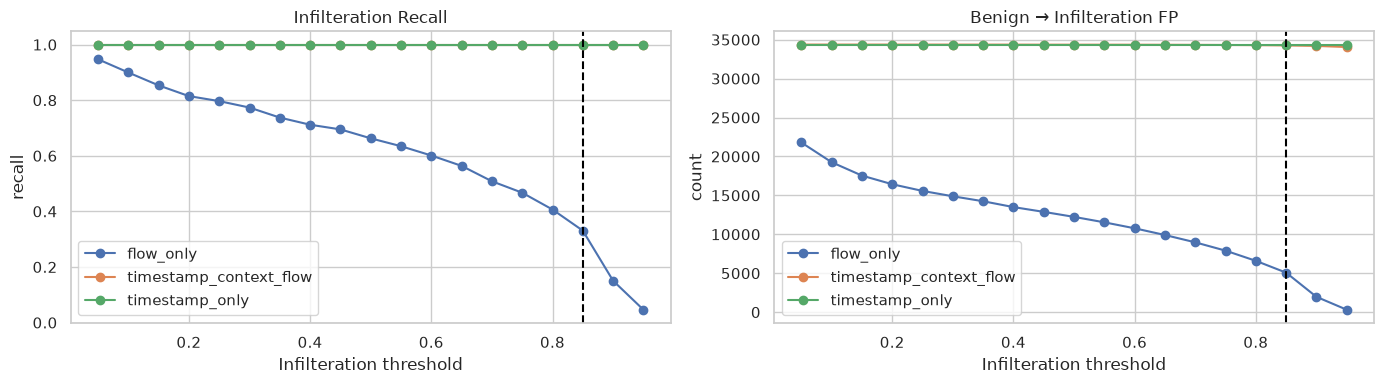

In [9]:
champion_report, champion_cm = save_evaluation(
    "v7_residual_champion", y_valid, champion_pred
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for feature_set, group in candidates[
    candidates["known_threshold"] == selected_known_threshold
].groupby("feature_set"):
    group = group.sort_values("inf_threshold")
    axes[0].plot(group["inf_threshold"], group["infilteration_recall"], marker="o", label=feature_set)
    axes[1].plot(group["inf_threshold"], group["benign_to_infilteration_fp"], marker="o", label=feature_set)
axes[0].set(title="Infilteration Recall", xlabel="Infilteration threshold", ylabel="recall")
axes[1].set(title="Benign → Infilteration FP", xlabel="Infilteration threshold", ylabel="count")
for ax in axes:
    ax.axvline(selected_inf_threshold, color="black", linestyle="--")
    ax.legend()
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v7_residual_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()


## 7. 날짜 Holdout 진단 — 2월 28일까지 학습, 3월 1일 검증

선택된 Residual 모델이 정확한 날짜를 외운 것인지 확인하기 위해 Stage 2만 별도로 재학습합니다.


In [10]:
holdout_frame = X_stage2_sets[selected_feature_set]
holdout_train_mask = (
    y_all.isin(["Benign", INFILTRATION_LABEL])
    & (train_df["Timestamp"] < pd.Timestamp("2018-03-01"))
)
holdout_valid_mask = (
    y_all.isin(["Benign", INFILTRATION_LABEL])
    & (train_df["Timestamp"] >= pd.Timestamp("2018-03-01"))
    & (train_df["Timestamp"] < pd.Timestamp("2018-03-02"))
)

holdout_y_train = (y_all.loc[holdout_train_mask] == INFILTRATION_LABEL).astype(int)
holdout_y_valid = (y_all.loc[holdout_valid_mask] == INFILTRATION_LABEL).astype(int)
holdout_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.asarray([0, 1]),
    y=holdout_y_train.to_numpy(),
)
holdout_weights = dict(zip([0, 1], holdout_weight_values.astype(float)))
holdout_weights[1] *= RESIDUAL_INF_WEIGHT_MULTIPLIER
holdout_model = Pipeline([
    ("preprocess", make_preprocessor(holdout_frame)),
    ("model", make_lgbm("binary", holdout_weights, n_estimators=400)),
])
holdout_model.fit(holdout_frame.loc[holdout_train_mask], holdout_y_train)
holdout_probability = holdout_model.predict_proba(
    holdout_frame.loc[holdout_valid_mask]
)[:, 1]
holdout_pred = (holdout_probability >= selected_inf_threshold).astype(int)

hp, hr, hf, _ = precision_recall_fscore_support(
    holdout_y_valid, holdout_pred, labels=[1], average=None, zero_division=0
)
holdout_metrics = {
    "holdout_precision": float(hp[0]),
    "holdout_recall": float(hr[0]),
    "holdout_f1": float(hf[0]),
    "holdout_accuracy": float(accuracy_score(holdout_y_valid, holdout_pred)),
    "holdout_train_rows": int(holdout_train_mask.sum()),
    "holdout_valid_rows": int(holdout_valid_mask.sum()),
    "holdout_valid_infilteration": int(holdout_y_valid.sum()),
}
print("Date holdout metrics:", holdout_metrics)
display(pd.crosstab(
    pd.Series(holdout_y_valid, name="actual"),
    pd.Series(holdout_pred, name="predicted"),
))


Date holdout metrics: {'holdout_precision': 0.2813321647677476, 'holdout_recall': 0.13920208152645272, 'holdout_f1': 0.18624891209747607, 'holdout_accuracy': 0.6608632571635836, 'holdout_train_rows': 141060, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306}


predicted,0,1
actual,,
0,145,32
1,83,16


## 8. MLflow 기록 및 전체 샘플 재학습

In [11]:
selected_stage2 = stage2_models[selected_feature_set]

with mlflow.start_run(run_name="v7_residual_champion_validation") as validation_run:
    mlflow.set_tags({
        "project": PROJECT_NAME,
        "hypothesis_id": HYPOTHESIS_ID,
        "hypothesis": HYPOTHESIS,
        "model_structure": "known_attacks_then_residual",
        "selection_tier": selection_tier,
        "validation": "within_class_chronological_80_20",
    })
    mlflow.log_params({
        "stage2_feature_set": selected_feature_set,
        "known_attack_threshold": selected_known_threshold,
        "infilteration_threshold": selected_inf_threshold,
        "candidate_count": len(candidates),
    })
    mlflow.log_metrics({**champion_metrics, **holdout_metrics})
    mlflow.log_artifact(str(candidates_path), artifact_path="search")
    mlflow.log_artifact(str(champion_report), artifact_path="evaluation")
    mlflow.log_artifact(str(champion_cm), artifact_path="evaluation")
    mlflow.log_artifact(str(tradeoff_path), artifact_path="evaluation")
    mlflow.sklearn.log_model(
        attack_gate, name="stage1_attack_gate",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        attack_subtype, name="stage1_attack_subtype",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        selected_stage2, name="stage2_residual_specialist",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    validation_run_id = validation_run.info.run_id

final_attack_gate = clone(attack_gate)
final_attack_subtype = clone(attack_subtype)
final_stage2 = clone(selected_stage2)
y_attack_binary_all = (y_all != "Benign").astype(int)
attack_all_mask = y_all != "Benign"
residual_all_mask = y_all.isin(["Benign", INFILTRATION_LABEL])
y_residual_all = (y_all.loc[residual_all_mask] == INFILTRATION_LABEL).astype(int)

with mlflow.start_run(run_name="v7_residual_full_refit") as final_run:
    mlflow.set_tags({
        "project": PROJECT_NAME,
        "hypothesis_id": HYPOTHESIS_ID,
        "stage": "full_sample_refit",
        "model_structure": "known_attacks_then_residual",
    })
    mlflow.log_params({
        "stage2_feature_set": selected_feature_set,
        "known_attack_threshold": selected_known_threshold,
        "infilteration_threshold": selected_inf_threshold,
        "train_rows": len(y_all),
        "residual_train_rows": int(residual_all_mask.sum()),
        "source_validation_run_id": validation_run_id,
    })
    started = time.time()
    final_attack_gate.fit(X_router, y_attack_binary_all)
    final_attack_subtype.fit(X_router.loc[attack_all_mask], y_all.loc[attack_all_mask])
    final_stage2.fit(
        X_stage2_sets[selected_feature_set].loc[residual_all_mask],
        y_residual_all,
    )
    mlflow.log_metric("train_seconds", time.time() - started)
    mlflow.sklearn.log_model(
        final_attack_gate, name="stage1_attack_gate",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        final_attack_subtype, name="stage1_attack_subtype",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        final_stage2, name="stage2_residual_specialist",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    final_run_id = final_run.info.run_id

print("Validation run:", validation_run_id)
print("Final run     :", final_run_id)


2026/08/15 16:59:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 16:59:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 16:59:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v7_residual_champion_validation at: http://mlflow:5000/#/experiments/6/runs/6aff4eaa41d74cf29bf5bfb3257633d7
🧪 View experiment at: http://mlflow:5000/#/experiments/6


2026/08/15 16:59:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 16:59:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 16:59:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v7_residual_full_refit at: http://mlflow:5000/#/experiments/6/runs/cc5ba8ad0be1499b90abbb9d44c50ba2
🧪 View experiment at: http://mlflow:5000/#/experiments/6
Validation run: 6aff4eaa41d74cf29bf5bfb3257633d7
Final run     : cc5ba8ad0be1499b90abbb9d44c50ba2


## 9. Test 예측과 제출 검증

In [12]:
def load_full(path: Path):
    with duckdb.connect() as con:
        return con.execute(f"SELECT * FROM {parquet_expr(path)}").df()

test_df = add_ids_features(load_full(TEST_TEMPORAL))
test_ids = test_df[ID_COL].copy()
X_test_full = test_df.drop(columns=[TARGET, ID_COL, "Timestamp"], errors="ignore")
X_test_flow = X_test_full.drop(columns=TEMPORAL_FEATURES, errors="ignore")
X_test_router = X_test_full.drop(columns=CALENDAR_FEATURES, errors="ignore")
X_test_timestamp = X_test_full[CALENDAR_FEATURES].copy()
X_test_stage2_sets = {
    "flow_only": X_test_flow,
    "timestamp_only": X_test_timestamp,
    "timestamp_context_flow": X_test_full,
}
for frame in [X_test_flow, X_test_router, X_test_timestamp, X_test_full]:
    for column in CAT_FEATURES:
        if column in frame.columns:
            frame[column] = frame[column].astype("string")

X_test_router = X_test_router[X_router.columns]
X_test_stage2 = X_test_stage2_sets[selected_feature_set][
    X_stage2_sets[selected_feature_set].columns
]

test_attack_probability = final_attack_gate.predict_proba(X_test_router)[:, 1]
test_router_label = final_attack_subtype.predict(X_test_router)
test_accept_known = (
    np.isin(test_router_label, KNOWN_ATTACKS)
    & (test_attack_probability >= selected_known_threshold)
)
test_inf_probability = final_stage2.predict_proba(X_test_stage2)[:, 1]
test_residual_pred = np.where(
    test_inf_probability >= selected_inf_threshold,
    INFILTRATION_LABEL,
    "Benign",
)
test_pred = np.where(test_accept_known, test_router_label, test_residual_pred)

submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred}).set_index(ID_COL)
submission_path = OUTPUT_DIR / "submission_v7.csv"
submission.to_csv(submission_path, encoding="utf-8-sig")
checks = {
    "rows": len(submission),
    "expected_rows": len(test_df),
    "label_missing": int(submission[TARGET].isna().sum()),
    "duplicate_id": int(submission.index.duplicated().sum()),
    "unknown_labels": sorted(set(submission[TARGET]) - set(classes)),
}
print("Saved:", submission_path)
print("Checks:", checks)
display(submission[TARGET].value_counts().to_frame("count"))
assert checks["rows"] == checks["expected_rows"]
assert checks["label_missing"] == 0
assert checks["duplicate_id"] == 0
assert not checks["unknown_labels"]


Saved: /home/jovyan/work/network-classification/outputs/v7/submission_v7.csv
Checks: {'rows': 1159701, 'expected_rows': 1159701, 'label_missing': 0, 'duplicate_id': 0, 'unknown_labels': []}


,count
Label,
Benign,815181
DoS,141518
DDOS,125639
Brute Force,76088
Infilteration,1275


## 10. 가설 판정

In [13]:
hypothesis_supported = (
    champion_metrics["infilteration_recall"] >= 0.60
    and champion_metrics["accuracy"] >= 0.90
    and champion_metrics["benign_to_infilteration_fp"] <= 3500
    and champion_metrics["infilteration_f1"] > V6_BASELINE["infilteration_f1"]
)

summary = pd.DataFrame([
    {"model": "v6_baseline", **V6_BASELINE},
    {"model": "v7_champion", **champion_metrics},
])
summary_path = OUTPUT_DIR / "v7_champion_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
display(summary)

print("Hypothesis supported:", hypothesis_supported)
print("Selection tier      :", selection_tier)
print("Date holdout        :", holdout_metrics)
print("Validation run      :", validation_run_id)
print("Final run           :", final_run_id)
print("Submission          :", submission_path)


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_f1,ddos_f1,dos_f1,bruteforce_precision,bruteforce_recall,ddos_precision,ddos_recall,dos_precision,dos_recall,infilteration_routed_to_known
0,v6_baseline,0.920251,0.754148,0.908938,0.092655,0.459459,0.154212,3496,0.920461,0.994183,0.947735,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,v7_champion,0.916607,0.736528,0.875310,0.048227,0.330759,0.084179,5072,0.920461,0.994183,0.947289,0.855315,0.996349,1.0,0.988433,0.998809,0.900823,0.0


Hypothesis supported: False
Selection tier      : fallback
Date holdout        : {'holdout_precision': 0.2813321647677476, 'holdout_recall': 0.13920208152645272, 'holdout_f1': 0.18624891209747607, 'holdout_accuracy': 0.6608632571635836, 'holdout_train_rows': 141060, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306}
Validation run      : 6aff4eaa41d74cf29bf5bfb3257633d7
Final run           : cc5ba8ad0be1499b90abbb9d44c50ba2
Submission          : /home/jovyan/work/network-classification/outputs/v7/submission_v7.csv
